# Semantic Benchmark Readable Analysis

This notebook focuses on **Requirement vs Best Match** and lets you choose a report config manually.

Manual controls are in the next cell: `REPORT_CONFIG`, `DISPLAY_TOP_N`, `PRINT_FULL_TABLE`.


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

benchmark_root = Path('../../Results/semantic-evaluation')
metrics_path = benchmark_root / 'metrics.csv'
runs_root = benchmark_root / 'runs'

print('Metrics path:', metrics_path.resolve())
metrics = pd.read_csv(metrics_path)
display(metrics)


Metrics path: /Users/ChiThien/Saveloads/HDA/PPundBA/Website-to-learn-German/Results/semantic-evaluation/metrics.csv


,CONFIG,BACKEND,SEMANTIC_WEIGHT,LEXICAL_WEIGHT,TOTAL_REQ,AUTO,REVIEW,NO_MATCH,AUTO_RATE,COVERAGE_RATE,AVG_TOP1_SCORE,AVG_TOP1_SEMANTIC,AVG_TOP1_LEXICAL,EFFICIENCY_INDEX,STATUS,OUTPUT_DIR,NOTES
0,local_semantic_only,local,1.00,0.00,9,7,0,2,0.7778,0.7778,0.4572,0.4572,0.3262,0.7778,SUCCESS,/Users/ChiThien/Saveloads/HDA/PPundBA/Website-...,Requirements processed: 9\nKeywords in scope: ...
1,local_hybrid_85_15,local,0.85,0.15,9,7,0,2,0.7778,0.7778,0.4396,0.4572,0.3397,0.7778,SUCCESS,/Users/ChiThien/Saveloads/HDA/PPundBA/Website-...,Requirements processed: 9\nKeywords in scope: ...
2,local_hybrid_70_30,local,0.70,0.30,9,7,0,2,0.7778,0.7778,0.4220,0.4572,0.3397,0.7778,SUCCESS,/Users/ChiThien/Saveloads/HDA/PPundBA/Website-...,Requirements processed: 9\nKeywords in scope: ...
3,sentence_semantic_only,sentence-transformers,1.00,0.00,9,8,0,1,0.8889,0.8889,0.5467,0.5467,0.3278,0.8889,SUCCESS,/Users/ChiThien/Saveloads/HDA/PPundBA/Website-...,Requirements processed: 9\nKeywords in scope: ...
4,sentence_hybrid_85_15,sentence-transformers,0.85,0.15,9,7,1,1,0.7778,0.8889,0.5138,0.5467,0.3278,0.8333,SUCCESS,/Users/ChiThien/Saveloads/HDA/PPundBA/Website-...,Requirements processed: 9\nKeywords in scope: ...
5,sentence_hybrid_70_30,sentence-transformers,0.70,0.30,9,6,2,1,0.6667,0.8889,0.4810,0.5467,0.3278,0.7778,SUCCESS,/Users/ChiThien/Saveloads/HDA/PPundBA/Website-...,Requirements processed: 9\nKeywords in scope: ...


In [2]:
# Manual controls
REPORT_CONFIG = None  # Example: 'local_hybrid_85_15'. Keep None to auto-select best.
DISPLAY_TOP_N = 0     # 0 = show all rows
PRINT_FULL_TABLE = False  # True = display full selected table

available_configs = metrics['CONFIG'].tolist()
print('Available configs:', available_configs)

if REPORT_CONFIG is None:
    metrics_sorted = metrics.sort_values(
        by=['EFFICIENCY_INDEX', 'COVERAGE_RATE', 'AUTO'],
        ascending=False
    )
    selected_config = metrics_sorted.iloc[0]['CONFIG']
    print('Selected config (auto-best):', selected_config)
else:
    if REPORT_CONFIG not in available_configs:
        raise ValueError(f'Unknown REPORT_CONFIG: {REPORT_CONFIG}. Use one of: {available_configs}')
    selected_config = REPORT_CONFIG
    print('Selected config (manual):', selected_config)


Available configs: ['local_semantic_only', 'local_hybrid_85_15', 'local_hybrid_70_30', 'sentence_semantic_only', 'sentence_hybrid_85_15', 'sentence_hybrid_70_30']
Selected config (auto-best): sentence_semantic_only


In [3]:
mapping_path = runs_root / selected_config / 'mapping_report.csv'
mapping = pd.read_csv(mapping_path)
best_match = mapping[[
    'REQ_ID',
    'REQUIREMENT_TEXT',
    'REQUIREMENT_TYPE',
    'STATUS',
    'MATCH_1_KEYWORD',
    'MATCH_1_SCORE',
    'MATCH_1_MODULE',
    'NLP_ACTIONS'
]].rename(columns={
    'MATCH_1_KEYWORD': 'BEST_MATCH_KEYWORD',
    'MATCH_1_SCORE': 'BEST_MATCH_SCORE',
    'MATCH_1_MODULE': 'BEST_MATCH_MODULE'
})

if DISPLAY_TOP_N and DISPLAY_TOP_N > 0:
    best_match_view = best_match.head(DISPLAY_TOP_N)
else:
    best_match_view = best_match

print('Mapping path:', mapping_path.resolve())
print('Rows selected for display/export:', len(best_match_view), 'of', len(best_match))

if PRINT_FULL_TABLE:
    display(best_match_view)
else:
    display(best_match_view.head(20))


Mapping path: /Users/ChiThien/Saveloads/HDA/PPundBA/Website-to-learn-German/Results/semantic-evaluation/runs/sentence_semantic_only/mapping_report.csv
Rows selected for display/export: 9 of 9


,REQ_ID,REQUIREMENT_TEXT,REQUIREMENT_TYPE,STATUS,BEST_MATCH_KEYWORD,BEST_MATCH_SCORE,BEST_MATCH_MODULE,NLP_ACTIONS
0,REQ-001,"As a user, I want to log in using ""test@gmail....",user_story,AUTO_SUGGEST,the user signs in with email '${Email}' and pa...,0.6310,login,NaN
1,REQ-002,I want to sign in with my email and password s...,general_requirement,AUTO_SUGGEST,the user signs in with email '${Email}' and pa...,0.6524,login,the user signs in with email '${Email}' and pa...
2,REQ-003,"As a user, I want to perform login and navigat...",user_story,AUTO_SUGGEST,the user go to sign in page,0.6127,login,the user navigates to the 'challenge' page
3,REQ-004,"As a user, I want to open the challenge tab af...",user_story,AUTO_SUGGEST,the user go to sign in page,0.5871,login,the user navigates to the 'challenge' page
4,REQ-005,"As a user, I want to open the sign up page fro...",user_story,AUTO_SUGGEST,the user go to sign in page,0.7054,login,the user navigates to the 'register from sign...
5,REQ-006,The system should display an error notificatio...,bug_report,AUTO_SUGGEST,the '${Notification}' notification should be v...,0.5409,Common,the '${Notification}' notification should be v...
6,REQ-007,The system must show the Remember Me checkbox ...,functional_requirement,AUTO_SUGGEST,the '${Checkbox}' checkbox should be visible,0.5196,Common,the '${Checkbox}' checkbox should be visible
7,REQ-008,the confirmation message does not appear.,general_requirement,AUTO_SUGGEST,the sign in error should contain '${Text}',0.4583,login,NaN
8,REQ-009,Issue: ranking filter fails when selecting thi...,bug_report,NO_MATCH,the user clicks the '${Button}' button at inde...,0.2126,Common,"the user clicks the 'logout, this month' button"


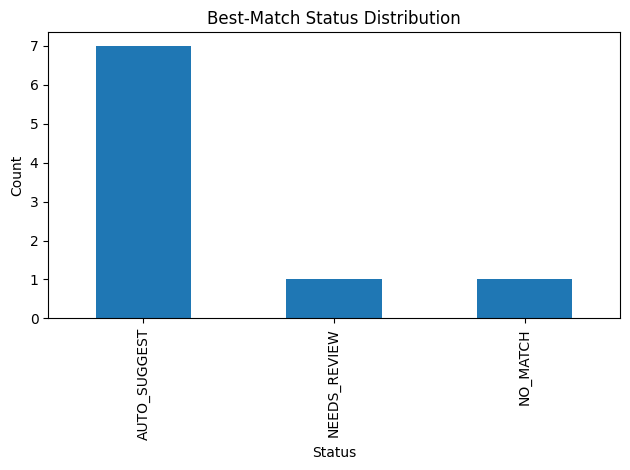

In [5]:
status_counts = best_match['STATUS'].value_counts()
status_counts.plot(kind='bar', title='Best-Match Status Distribution')
plt.xlabel('Status')
plt.ylabel('Count')
plt.tight_layout()


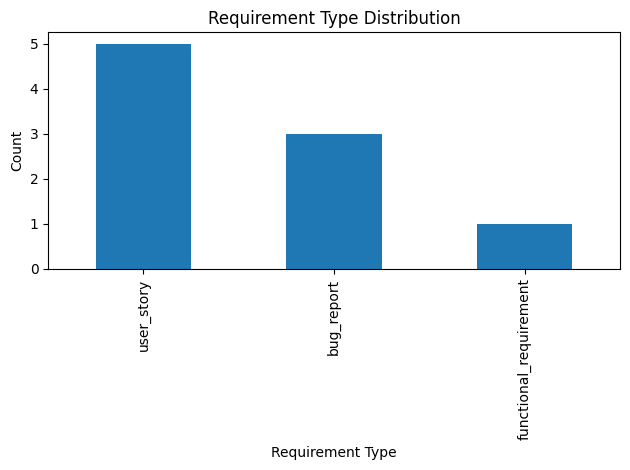

In [6]:
type_counts = best_match['REQUIREMENT_TYPE'].value_counts()
type_counts.plot(kind='bar', title='Requirement Type Distribution')
plt.xlabel('Requirement Type')
plt.ylabel('Count')
plt.tight_layout()


In [ ]:
display(metrics[metrics['CONFIG'] == selected_config])

ax = metrics.plot(
    x='CONFIG',
    y='EFFICIENCY_INDEX',
    kind='bar',
    title='Efficiency Index by Configuration'
)
ax.set_ylabel('Efficiency Index')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()


In [ ]:
output_dir = benchmark_root / 'notebook-exports'
output_dir.mkdir(parents=True, exist_ok=True)

export_df = best_match_view.copy()
base_name = f'best_match_table_{selected_config}'

csv_path = output_dir / f'{base_name}.csv'
md_path = output_dir / f'{base_name}.md'
tex_path = output_dir / f'{base_name}.tex'

export_df.to_csv(csv_path, index=False)
export_df.to_markdown(md_path, index=False)
export_df.to_latex(tex_path, index=False)

print('Exported files:')
print('-', csv_path)
print('-', md_path)
print('-', tex_path)
